# Testing the noise covariance using fgbuster

The goal here is to import the noise covariance computed in the pipeline and see if the reults coming out of fgbuster are correct

The test will follow these general steps:
 1. First we will use the full sky data and noise covariance before preprocessing. This should give a close to perfect result.
 2. Then we will do the same on data and noise covariance **after** preprocessing.
 3. Then we go back to data and noise cov **before** preprocessing, but this time a mak and nhits we have been repectively applied to the data and the noise sims used to compute the noise covariance.
 4. Finally we will perform the test on the most realistic case, with **preproceseed** and masked data and noise-covariance
 5. We will also test the importance of using a noise covariance that was built using noise map simulations that went through preprocessing. To test this we will use data that went through preprocessing, but a noise covariance that did not (but we still apply the nhits maps to the it)

# 1) Full sky, before preprocessing


In [1]:
#  Importing the relevant libraries
import numpy as np
import matplotlib.pyplot as plt
import fgbuster as fg
from fgbuster.component_model import CMB, Dust, Synchrotron
from megatop import BBmeta
import healpy as hp
import os
import time
from pysm3 import Sky
import scipy
from scipy import stats
from tqdm import tqdm

In [2]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32NONhits
# Let's set up the meta_sims and meta objects.
args = classmethod(None)
args.sims = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32NONhits/OnTheFlySims/config.yaml'
args.globals = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32NONhits/outputs/config.yaml'

meta_sims = BBmeta(args.sims)
meta = BBmeta(args.globals)

In [3]:
# Now let's load the data for the first simulation.
sim_num = 0
freq_maps_full_sky_beforepreproc = np.load(os.path.join(meta_sims.comb_directory, 'comb_freq_maps_SIM'+str(sim_num).zfill(5)+'.npy' ))

#  And the relevant noise covariance matrix
# careful, the noise covariance is a product of the pipeline (different from simulations) and its relevant parameters/path are stored in the meta object (not meta_sims)
noise_cov_full_sky_beforepreproc = np.load(os.path.join(meta.covmat_directory, 'pixel_noise_cov.npy' ))

Frequency =  93 GHz


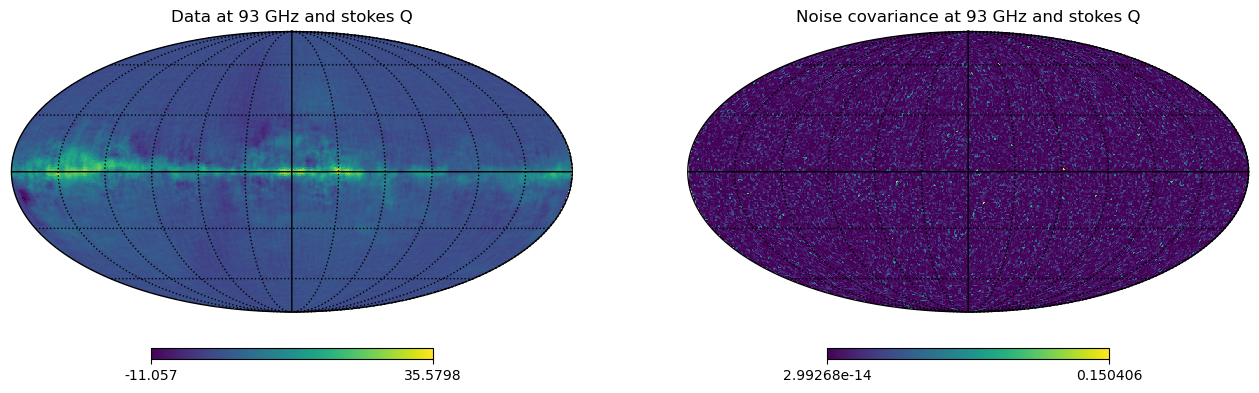

In [4]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_full_sky_beforepreproc[freq_index, stokes_index, :], title='Data at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_full_sky_beforepreproc[freq_index, stokes_index, :], title='Noise covariance at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()


In [5]:
# Now let's set up the component separation
instrument = {'frequency': meta.frequencies}
components = [CMB(), Dust(150., temp=20.0), Synchrotron(150.)] # we leave T_dust fixed at 20 K

# Minimization options, copied from BBPipe
options={'disp':False, 'gtol': 1e-12, 'eps': 1e-12, 'maxiter': 100, 'ftol': 1e-12 } 
tol=1e-18
method='TNC'

# And run the separation
time_comp_sep = time.time()
res_full_sky_beforepreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_full_sky_beforepreproc[:,1:], cov=noise_cov_full_sky_beforepreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print('success: ',res_full_sky_beforepreproc.success)
print('x: ', res_full_sky_beforepreproc.x)

time comp sep = 24.150533199310303
success:  True
x:  [ 1.53628218 -2.96305171]


In [6]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_full_sky_beforepreproc.Sigma)

    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_full_sky_beforepreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_full_sky_beforepreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)  

    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_full_sky_beforepreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_full_sky_beforepreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_full_sky_beforepreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_full_sky_beforepreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_full_sky_beforepreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_full_sky_beforepreproc.x[1])/ sigma_from_fisher[1,1] )
    

Checking difference with input d0 s0 indices


Input dust index =  1.54           Estimated dust index =  1.5362821783946605
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.963051709381796
Estimated error matrix = 
 [[ 1.08039506e-04 -2.98565820e-05]
 [-2.98565820e-05  3.98524894e-04]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0037178216053395108
Relative difference in dust index (in %) =  0.24141698735970848
Relative difference in dust index using ouptut Sigma =  34.411686435477485



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.03694829061820393
Relative difference in synchrotron index (in %) =  1.231609687273464
Relative difference in synchrotron index using ouptut Sigma =  92.71262897346247


# 2) Data and noise covariance **after** preprocessing

In [7]:
# Let's import the pre-processed data and noise covariance matrix
freq_maps_full_sky_afterpreproc = np.load(os.path.join(meta.pre_process_directory, 'freq_maps_common_beamed'+str(sim_num).zfill(5)+'.npy' ))

noise_cov_full_sky_afterpreproc = np.load(os.path.join(meta.covmat_directory, 'pixel_noise_cov_preprocessed.npy' ))

Frequency =  93 GHz


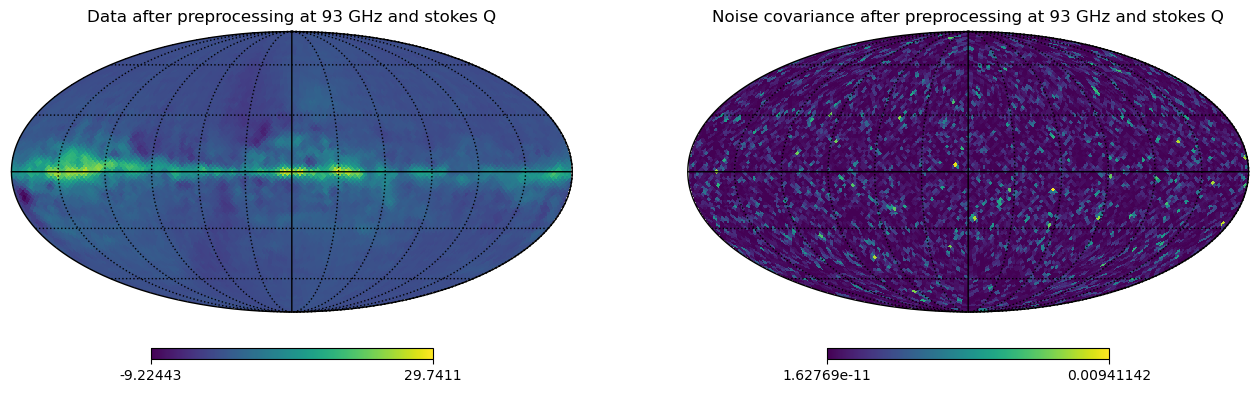

In [8]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_full_sky_afterpreproc[freq_index, stokes_index, :], title='Data after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_full_sky_afterpreproc[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [9]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_full_sky_afterpreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_full_sky_afterpreproc[:,1:], cov=noise_cov_full_sky_afterpreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print('success: ',res_full_sky_afterpreproc.success)
print('x: ', res_full_sky_afterpreproc.x)

time comp sep = 1.4579236507415771
success:  True
x:  [ 1.54018258 -3.00039023]


In [10]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_full_sky_afterpreproc.Sigma)
    
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_full_sky_afterpreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_full_sky_afterpreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)    

    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_full_sky_afterpreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_full_sky_afterpreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_full_sky_afterpreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_full_sky_afterpreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_full_sky_afterpreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_full_sky_afterpreproc.x[1])/ sigma_from_fisher[1,1] )
    

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5401825762404044
Input synchrotron index =  -3.0    Estimated synchrotron index =  -3.000390228927275
Estimated error matrix = 
 [[ 6.23940345e-05 -2.18390221e-05]
 [-2.18390221e-05  2.88772532e-04]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.00018257624040440845
Relative difference in dust index (in %) =  0.011855600026260288
Relative difference in dust index using ouptut Sigma =  2.9261810328789064



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.00039022892727480496
Relative difference in synchrotron index (in %) =  0.013007630909160165
Relative difference in synchrotron index using ouptut Sigma =  1.3513367234146965


# 3) Data and noise cov **before** preprocessing, **masked** 
This time a mask and nhits map has been repectively applied to the data and the noise sims used to compute the noise covariance.

In [11]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits
# Let's set up the meta_sims and meta objects.
args_nhits = classmethod(None)
args_nhits.sims = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhitsCorrected/OnTheFlySims/config.yaml'
args_nhits.globals = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhitsCorrected/outputs/config.yaml'

meta_nhits_sims = BBmeta(args_nhits.sims)
meta_nhits = BBmeta(args_nhits.globals)

In [12]:
# Let's import the masked data and noise covariance matrix
binary_mask_sims = meta_nhits_sims.read_mask('binary').astype(bool)
freq_maps_masked_beforepreproc = np.load(os.path.join(meta_nhits_sims.comb_directory, 'comb_freq_maps_SIM'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_beforepreproc[..., np.where(binary_mask_sims == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_beforepreproc = np.load(os.path.join(meta_nhits.covmat_directory, 'pixel_noise_cov.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_beforepreproc[..., np.where(binary_mask_sims == 0)[0]] = hp.UNSEEN 


Frequency =  93 GHz


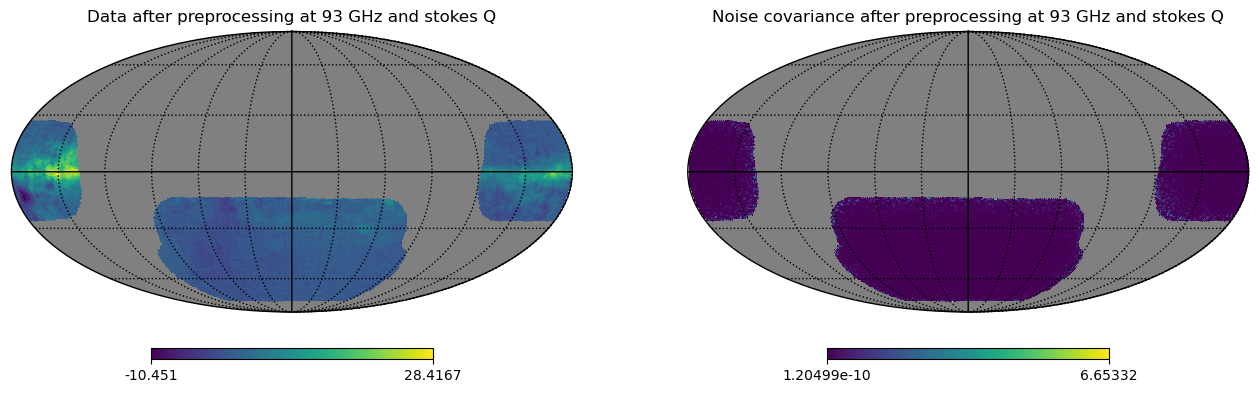

In [13]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_beforepreproc[freq_index, stokes_index, :], title='Data after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_beforepreproc[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [14]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_beforepreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_beforepreproc[:,1:], cov=noise_cov_masked_beforepreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print('success: ',res_masked_beforepreproc.success)
print('x: ', res_masked_beforepreproc.x)

time comp sep = 9.115569829940796
success:  True
x:  [ 1.53801553 -2.97969619]


In [15]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_beforepreproc.Sigma)
    
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_beforepreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_beforepreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)

    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_beforepreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_beforepreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_beforepreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_beforepreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_beforepreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_beforepreproc.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5380155297658495
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.979696191961664
Estimated error matrix = 
 [[ 0.00035205 -0.00011361]
 [-0.00011361  0.00197227]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0019844702341504927
Relative difference in dust index (in %) =  0.12886170351626577
Relative difference in dust index using ouptut Sigma =  5.636840744865476



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.02030380803833598
Relative difference in synchrotron index (in %) =  0.6767936012778659
Relative difference in synchrotron index using ouptut Sigma =  10.294657180991008


# 4)Most realistic case, with **preproceseed** and masked data and noise-covariance

In [16]:
# Let's import the masked data and noise covariance matrix
binary_mask = meta_nhits.read_mask('binary').astype(bool)
freq_maps_masked_afterpreproc = np.load(os.path.join(meta_nhits.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_afterpreproc[..., np.where(binary_mask == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_afterpreproc = np.load(os.path.join(meta_nhits.covmat_directory, 'pixel_noise_cov_preprocessed.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_afterpreproc[..., np.where(binary_mask == 0)[0]] = hp.UNSEEN 


Frequency =  93 GHz


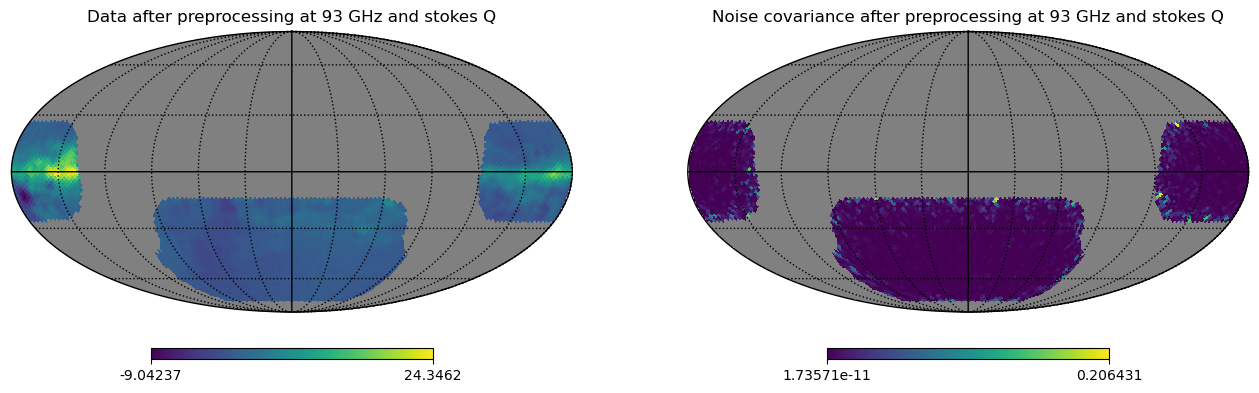

In [17]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_afterpreproc[freq_index, stokes_index, :], title='Data after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_afterpreproc[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [18]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_afterpreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc[:,1:], cov=noise_cov_masked_afterpreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print('success: ',res_masked_afterpreproc.success)
print('x: ', res_masked_afterpreproc.x)

time comp sep = 2.1383166313171387
success:  True
x:  [ 1.54060936 -3.00233912]


In [19]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc.Sigma)

    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5406093566694217
Input synchrotron index =  -3.0    Estimated synchrotron index =  -3.0023391216350066
Estimated error matrix = 
 [[ 2.28492269e-04 -8.55616454e-05]
 [-8.55616454e-05  1.32791489e-03]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0006093566694216346
Relative difference in dust index (in %) =  0.039568614897508736
Relative difference in dust index using ouptut Sigma =  2.666859020178886



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.0023391216350066024
Relative difference in synchrotron index (in %) =  0.07797072116688675
Relative difference in synchrotron index using ouptut Sigma =  1.7614996619018735


# 5) Data after preprocessing and masked, noise covariance from sims before preprocessing using nhits

We degrade the noise covariance build using simulations before preprocessing to the nside of the analysis, and apply the relevant nhits maps. Ideally the nhits map should be applied before preprocessing to mimic the real data, but fore some reason this gives an error later on in the component separation. To be discussed.

/tmp/ipykernel_292169/958355690.py:8: RuntimeWarning: divide by zero encountered in true_divide
  noise_cov_full_sky_beforepreproc_degraded = np.array([hp.ud_grade(noise_cov_freq / nhits_map_rescaled, nside_out=meta_nhits.nside) for noise_cov_freq in noise_cov_full_sky_beforepreproc])
/global/homes/j/jost/.conda/envs/megatop/lib/python3.9/site-packages/healpy/pixelfunc.py:1978: RuntimeWarning: invalid value encountered in multiply
  map_out = np.sum(mr * goods, axis=1).astype(type_out)


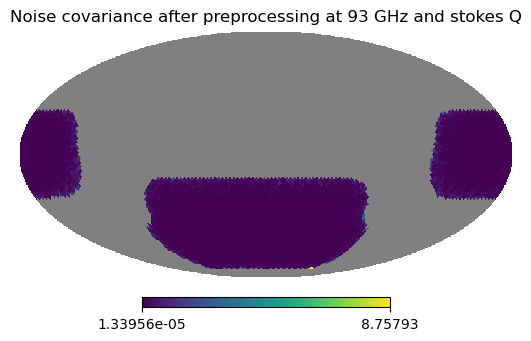

In [20]:
noise_cov_full_sky_beforepreproc = np.load(os.path.join(meta.covmat_directory, 'pixel_noise_cov.npy' ))

apply_nhits_before_udgrade = True # Doing it before yields an error in the component separation, I don't know why, the resulting noise covariance doesn't seem to have any ill defined values (e.g. 0, inf, nan, None...)
                                   # Applying it before would make more sense in my opinion though...
if apply_nhits_before_udgrade:
    nhits_map = meta_nhits_sims.read_hitmap() 
    nhits_map_rescaled = nhits_map / max(nhits_map)
    noise_cov_full_sky_beforepreproc_degraded = np.array([hp.ud_grade(noise_cov_freq / nhits_map_rescaled, nside_out=meta_nhits.nside) for noise_cov_freq in noise_cov_full_sky_beforepreproc])
else:
    noise_cov_full_sky_beforepreproc_degraded = np.array([hp.ud_grade(noise_cov_freq , nside_out=meta_nhits.nside) for noise_cov_freq in noise_cov_full_sky_beforepreproc])

    nhits_map = meta_nhits.read_hitmap() 
    nhits_map_rescaled = nhits_map / max(nhits_map)
    noise_cov_full_sky_beforepreproc_degraded /= nhits_map_rescaled

noise_cov_full_sky_beforepreproc_degraded[..., np.where(binary_mask == 0)[0]] = hp.UNSEEN 

hp.mollview(noise_cov_full_sky_beforepreproc_degraded[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.show()




In [21]:

time_comp_sep = time.time()
res_masked_afterpreproc_noisecovbeforepreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc[:,1:], cov=noise_cov_full_sky_beforepreproc_degraded[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print('success: ',res_masked_afterpreproc_noisecovbeforepreproc.success)
print('x: ', res_masked_afterpreproc_noisecovbeforepreproc.x)

time comp sep = 1.6011509895324707
success:  True
x:  [ 1.54180609 -2.99896792]


In [22]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc_noisecovbeforepreproc.Sigma)
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc_noisecovbeforepreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc_noisecovbeforepreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc_noisecovbeforepreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc_noisecovbeforepreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc_noisecovbeforepreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc_noisecovbeforepreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc_noisecovbeforepreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc_noisecovbeforepreproc.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.541806090815634
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.9989679229468607
Estimated error matrix = 
 [[ 0.00136729 -0.00052195]
 [-0.00052195  0.00852531]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0018060908156338762
Relative difference in dust index (in %) =  0.11727862439181014
Relative difference in dust index using ouptut Sigma =  1.320928583411207



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.0010320770531393464
Relative difference in synchrotron index (in %) =  0.03440256843797822
Relative difference in synchrotron index using ouptut Sigma =  0.12106037535273984


# 6) Re-exploring case (4) with **preproceseed** and masked data and noise-covariance but with noise covariance built using diffenrent number of simulations
### a) With nsims = 10

In [23]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits
# Let's set up the meta_sims and meta objects.
args_10 = classmethod(None)
args_10.sims = '/pscratch/sd/j/jost/SO_MEGATOP/10SimsNside64to32WithNhitsCorrected/OnTheFlySims/config.yaml'
args_10.globals = '/pscratch/sd/j/jost/SO_MEGATOP/10SimsNside64to32WithNhitsCorrected/outputs/config.yaml'

meta_10_sims = BBmeta(args_10.sims)
meta_10 = BBmeta(args_10.globals)

In [24]:
# Let's import the masked data and noise covariance matrix
binary_mask10 = meta_10.read_mask('binary').astype(bool)
freq_maps_masked_afterpreproc10 = np.load(os.path.join(meta_10.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_afterpreproc10[..., np.where(binary_mask10 == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_afterpreproc10 = np.load(os.path.join(meta_10.covmat_directory, 'pixel_noise_cov_preprocessed.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_afterpreproc10[..., np.where(binary_mask10 == 0)[0]] = hp.UNSEEN 

Frequency =  93 GHz


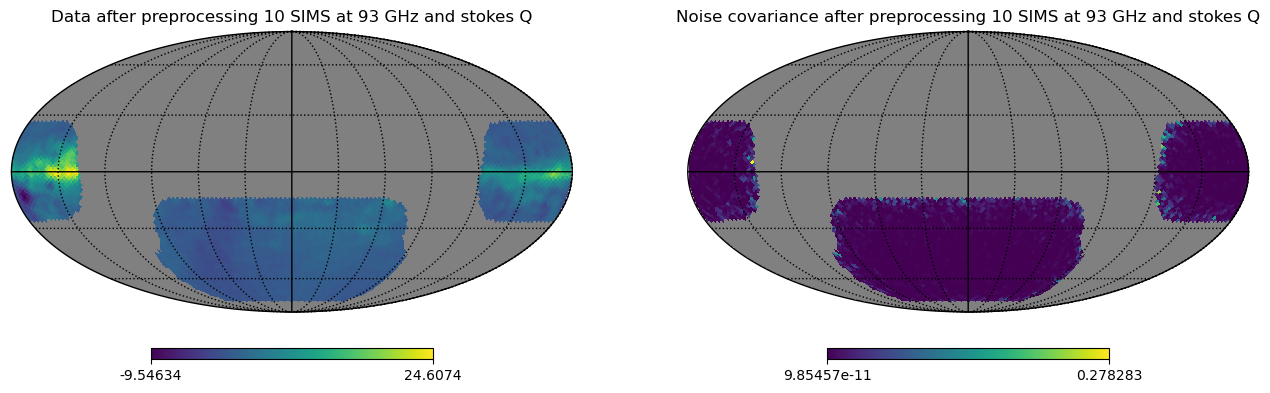

In [25]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_afterpreproc10[freq_index, stokes_index, :], title='Data after preprocessing 10 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_afterpreproc10[freq_index, stokes_index, :], title='Noise covariance after preprocessing 10 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [26]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_afterpreproc10 = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc10[:,1:], cov=noise_cov_masked_afterpreproc10[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print('success: ',res_masked_afterpreproc10.success)
print('x: ', res_masked_afterpreproc10.x)

time comp sep = 3.878911256790161
success:  True
x:  [ 1.54020812 -3.00130553]


In [27]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc10.Sigma)
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc10.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc10.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc10.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc10.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc10.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc10.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc10.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc10.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5402081237587824
Input synchrotron index =  -3.0    Estimated synchrotron index =  -3.001305526047873
Estimated error matrix = 
 [[ 2.16005509e-04 -6.86531030e-05]
 [-6.86531030e-05  1.20743022e-03]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.00020812375878231926
Relative difference in dust index (in %) =  0.01351452979105969
Relative difference in dust index using ouptut Sigma =  0.9635113471781332



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.0013055260478731512
Relative difference in synchrotron index (in %) =  0.04351753492910504
Relative difference in synchrotron index using ouptut Sigma =  1.0812434758812728


### b) With nsims = 250

In [28]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits
# Let's set up the meta_sims and meta objects.
args_250 = classmethod(None)
args_250.sims = '/pscratch/sd/j/jost/SO_MEGATOP/250SimsNside64to32WithNhitsCorrected/OnTheFlySims/config.yaml'
args_250.globals = '/pscratch/sd/j/jost/SO_MEGATOP/250SimsNside64to32WithNhitsCorrected/outputs/config.yaml'

meta_250_sims = BBmeta(args_250.sims)
meta_250 = BBmeta(args_250.globals)

In [29]:
# Let's import the masked data and noise covariance matrix
binary_mask250 = meta_250.read_mask('binary').astype(bool)
freq_maps_masked_afterpreproc250 = np.load(os.path.join(meta_250.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_afterpreproc250[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_afterpreproc250 = np.load(os.path.join(meta_250.covmat_directory, 'pixel_noise_cov_preprocessed.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_afterpreproc250[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN 

Frequency =  27 GHz


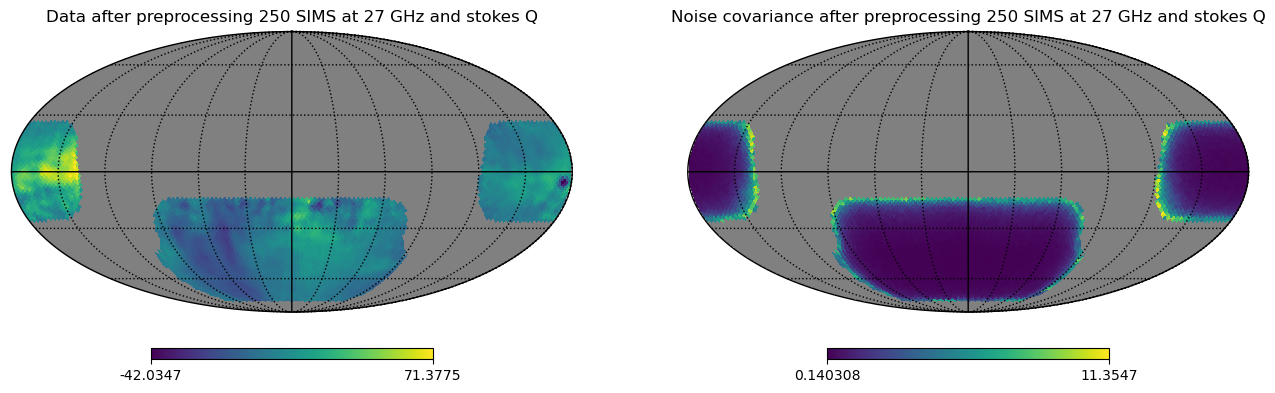

In [30]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 0
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q
from matplotlib import cm

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_afterpreproc250[freq_index, stokes_index, :], title='Data after preprocessing 250 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', 
            hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_afterpreproc250[freq_index, stokes_index, :], title='Noise covariance after preprocessing 250 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', 
            hold=True)
hp.graticule()
plt.show()

In [31]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_afterpreproc250 = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc250[:,1:], cov=noise_cov_masked_afterpreproc250[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print('success: ',res_masked_afterpreproc250.success)
print('x: ', res_masked_afterpreproc250.x)

time comp sep = 5.862154960632324
success:  True
x:  [ 1.53989673 -2.99636225]


In [32]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc250.Sigma)
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc250.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc250.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc250.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc250.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc250.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc250.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc250.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc250.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5398967340511496
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.996362250737189
Estimated error matrix = 
 [[ 0.00043388 -0.00017523]
 [-0.00017523  0.00293637]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0001032659488504617
Relative difference in dust index (in %) =  0.0067055810941858245
Relative difference in dust index using ouptut Sigma =  0.23800435432152453



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.0036377492628107966
Relative difference in synchrotron index (in %) =  0.12125830876035988
Relative difference in synchrotron index using ouptut Sigma =  1.2388611100962292


# 7) Comparing different simulations (input data)

We are keeping the same case as before i.e. data and noise cov after preprocessing, and masked / with nhits, and using 250 simulations for the noise covariance.

For now we will only compare the results of the first 50 simulations to give us a qualitative view.

In [33]:
# Let's import the masked data and noise covariance matrix
binary_mask250 = meta_250.read_mask('binary').astype(bool)
freq_maps_masked_afterpreproc250 = np.load(os.path.join(meta_250.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_afterpreproc250[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_afterpreproc250 = np.load(os.path.join(meta_250.covmat_directory, 'pixel_noise_cov_preprocessed.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_afterpreproc250[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN 

In [34]:
results_array = []
sigma_array = []
for sim_iter in tqdm(range(250)):
    freq_maps_masked_afterpreproc250 = np.load(os.path.join(meta_250.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_iter).zfill(5)+'.npy' )) 
    # Applying mask as it is not done in the simulation
    freq_maps_masked_afterpreproc250[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)
    res_masked_afterpreproc250_iter = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc250[:,1:], cov=noise_cov_masked_afterpreproc250[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
    if res_masked_afterpreproc250_iter.success:
        results_array.append(res_masked_afterpreproc250_iter.x)
        sigma_array.append(res_masked_afterpreproc250_iter.Sigma)
    # We can now check the results
    # print('iter #:', sim_iter, ',  success: ',res_masked_afterpreproc250_iter.success, ',  x: ', res_masked_afterpreproc250_iter.x)
results_array = np.array(results_array)
sigma_array = np.array(sigma_array)

100%|██████████| 250/250 [14:22<00:00,  3.45s/it]


Let's explore those results with histograms and compare with Gaussians centred at the mean of results_array, with std coming either from the mean of the "

In [35]:
def plot_hist_and_gaussian(results_array, sigma_array, sky):
    mean_sigma = scipy.linalg.sqrtm(np.mean(sigma_array,axis=0))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].hist(results_array[:,0], density=True, bins=20)
    range_bdust = np.linspace(min(results_array[:,0]), max(results_array[:,0]), 500)
    axes[0].plot(range_bdust, 
                scipy.stats.norm.pdf(range_bdust, loc=np.mean(results_array[:,0]), scale=mean_sigma[0,0]), label='Gaussian with mean = {:.4} and std = {:.2e}'.format(np.mean(results_array[:,0]),
                                                                                                                                                        mean_sigma[0,0]))
    axes[0].plot(range_bdust,
                scipy.stats.norm.pdf(range_bdust, loc=np.mean(results_array[:,0]), scale=np.std(results_array[:,0])), label='Gaussian with mean = {:.4} and std = {:.3e}'.format(np.mean(results_array[:,0]),
                                                                                                                                                                                    np.std(results_array[:,0])))
    axes[0].vlines(sky.components[0].mbb_index, 0, axes[0].set_ylim()[1] , color='black', linestyle='--', label='Input dust index = {:.4}'.format(sky.components[0].mbb_index))
    axes[0].set_title(r'$\beta_{\rm dust}$')
    axes[0].set_xlabel(r'$\beta_{\rm dust}$')
    axes[0].legend(loc='upper right')


    axes[1].hist(results_array[:,1] , density=True, bins=20)
    range_bsynch = np.linspace(min(results_array[:,1]), max(results_array[:,1]), 500)

    axes[1].plot(range_bsynch, 
                scipy.stats.norm.pdf(range_bsynch, loc=np.mean(results_array[:,1]), scale=mean_sigma[1,1]), label='Gaussian with mean = {:.4} and std = {:.2e}'.format(np.mean(results_array[:,1]),
                                                                                                                                                                        mean_sigma[1,1]))
    axes[1].plot(range_bsynch,
                scipy.stats.norm.pdf(range_bsynch, loc=np.mean(results_array[:,1]), scale=np.std(results_array[:,1])), label='Gaussian with mean = {:.4} and std = {:.3e}'.format(np.mean(results_array[:,1]),
                                                                                                                                                                                    np.std(results_array[:,1])))
    axes[1].vlines(sky.components[1].pl_index, 0, axes[1].set_ylim()[1] , color='black', linestyle='--', label='Input synch index = {:.4}'.format(sky.components[1].pl_index))

    axes[1].set_title(r'$\beta_{\rm synch}$')
    axes[1].set_xlabel(r'$\beta_{\rm synch}$')
    axes[1].legend(loc='upper right')
    plt.show()

    

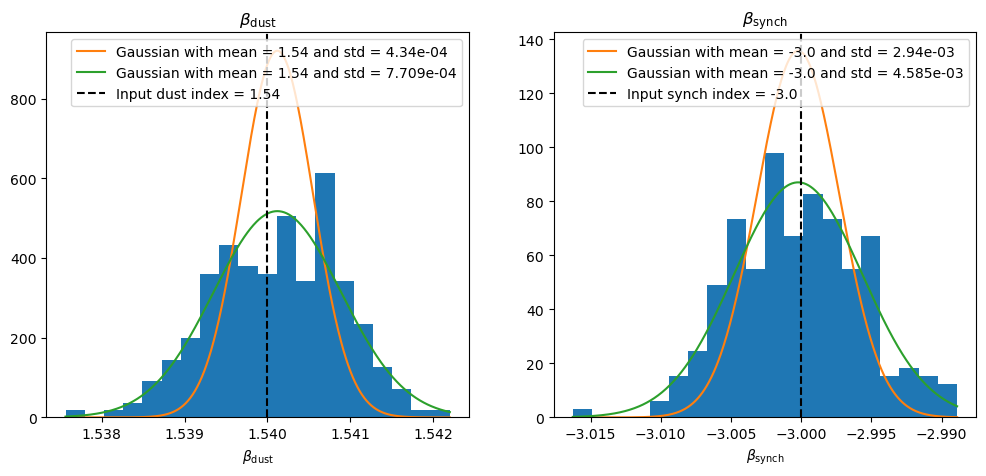

In [36]:
plot_hist_and_gaussian(results_array, sigma_array, sky)

## b) Using input white noise with nhits as noise covariance

In [37]:
import megatop.V3calc as V3
nhits_map_250 = meta_250.read_hitmap()
nhits_map_rescaled_250 = nhits_map_250 / max(nhits_map_250)

# Computing the white noise level
fsky_mask250 = sum(binary_mask250) / len(binary_mask250)
ell, N_ell_P_SA, Map_white_noise_levels = V3.so_V3_SA_noise(
        sensitivity_mode = meta_250.general_pars['sensitivity_mode'],
        one_over_f_mode = 2, # fixed to None since we only use white noise here
        SAC_yrs_LF = meta_250.general_pars['SAC_yrs_LF'], f_sky = fsky_mask250, 
        ell_max = meta_250.general_pars['lmax'], delta_ell=1,
        beam_corrected=False, remove_kluge=False, CMBS4='')

# Conversion from uK.arcmin to (uK)**2
print('Map_white_noise_levels uK . arcmin = ', Map_white_noise_levels)
white_noise_uK2 = ( Map_white_noise_levels / hp.nside2resol(meta_250.nside, arcmin=True))**2
print('white_noise_uK2 = ', white_noise_uK2)

# Creating a map out of white noise level (no randomness just smooth map)
map_white_noise = white_noise_uK2.reshape(white_noise_uK2.shape[0],1,1) *  np.ones( freq_maps_masked_afterpreproc250.shape )
print('map_white_noise.shape = ', map_white_noise.shape)       

# rescaling with nhits
map_white_noise_nhits = map_white_noise / nhits_map_rescaled_250
map_white_noise_nhits[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN        

SO configuration 
Map_white_noise_levels uK . arcmin =  [61.71102424 41.14068283  4.65454857  5.23636714 10.48726965 25.75820616]
white_noise_uK2 =  [0.31510049 0.14004466 0.00179258 0.00226873 0.00910015 0.05489778]
map_white_noise.shape =  (6, 3, 12288)


/tmp/ipykernel_292169/4066732470.py:24: RuntimeWarning: divide by zero encountered in true_divide
  map_white_noise_nhits = map_white_noise / nhits_map_rescaled_250


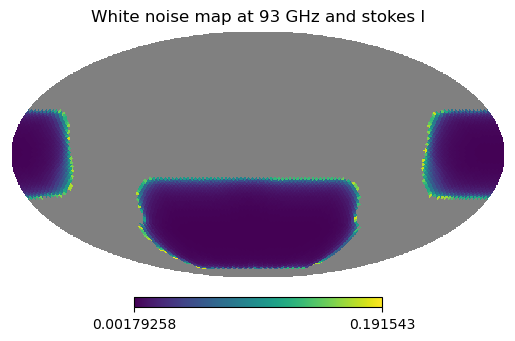

In [38]:
# Plotting one of the resulting noise covariance map
hp.mollview(map_white_noise_nhits[2,1], title='White noise map at 93 GHz and stokes I', hold=True)
plt.show()

In [39]:
# Proceeding with the separation on all 250 simulations
results_array_WN = []
sigma_array_WN = []
for sim_iter in tqdm(range(250)):
    freq_maps_masked_afterpreproc250_WN = np.load(os.path.join(meta_250.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_iter).zfill(5)+'.npy' )) 
    # Applying mask as it is not done in the simulation
    freq_maps_masked_afterpreproc250_WN[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)
    res_masked_afterpreproc250_iter_WN = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc250_WN[:,1:], cov=map_white_noise_nhits[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
    if res_masked_afterpreproc250_iter_WN.success:
        results_array_WN.append(res_masked_afterpreproc250_iter_WN.x)
        sigma_array_WN.append(res_masked_afterpreproc250_iter_WN.Sigma)
results_array_WN = np.array(results_array_WN)
sigma_array_WN = np.array(sigma_array_WN)

100%|██████████| 250/250 [12:11<00:00,  2.93s/it]


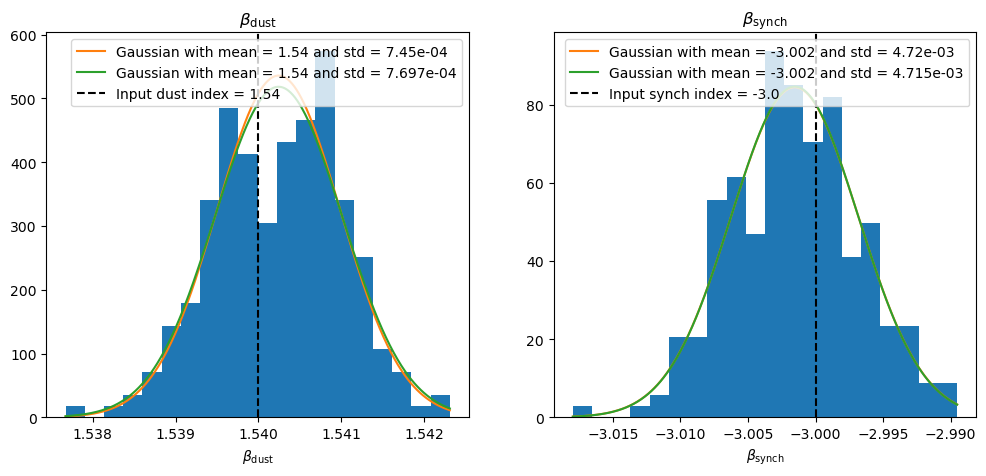

In [40]:
plot_hist_and_gaussian(results_array_WN, sigma_array_WN, sky)

## c) Reducing the sky fraction by moving the zero threshold to reduce possible edge effects

In [41]:
from megatop.utils import get_binary_mask_from_nhits
# Creating new binary mask with a more restrictive threshold of 1e-1
zero_threshold_centre = 1e-1
binary_centre = get_binary_mask_from_nhits(nhits_map_rescaled_250, meta_250.nside,
                                             zero_threshold=zero_threshold_centre)

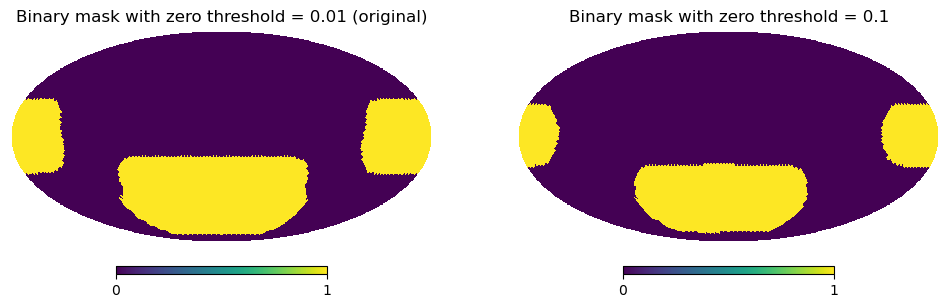

In [42]:
#  Plotting the two masks
fig , axes = plt.subplots(1, 2, figsize=(12, 6))
plt.sca(axes[0])
hp.mollview(binary_mask250, title='Binary mask with zero threshold = {} (original)'.format(meta_250.masks['mask_handler_binary_zero_threshold']), hold=True)
plt.sca(axes[1])
hp.mollview(binary_centre, title='Binary mask with zero threshold = {}'.format(zero_threshold_centre), hold=True)

Using the same colorbar for both plots (rescaled) for easier comparison


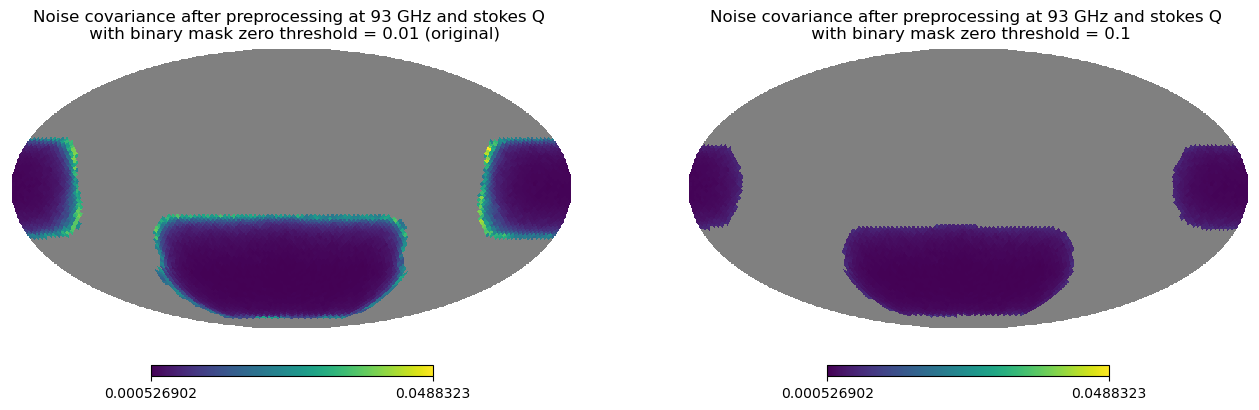

With default colorbar


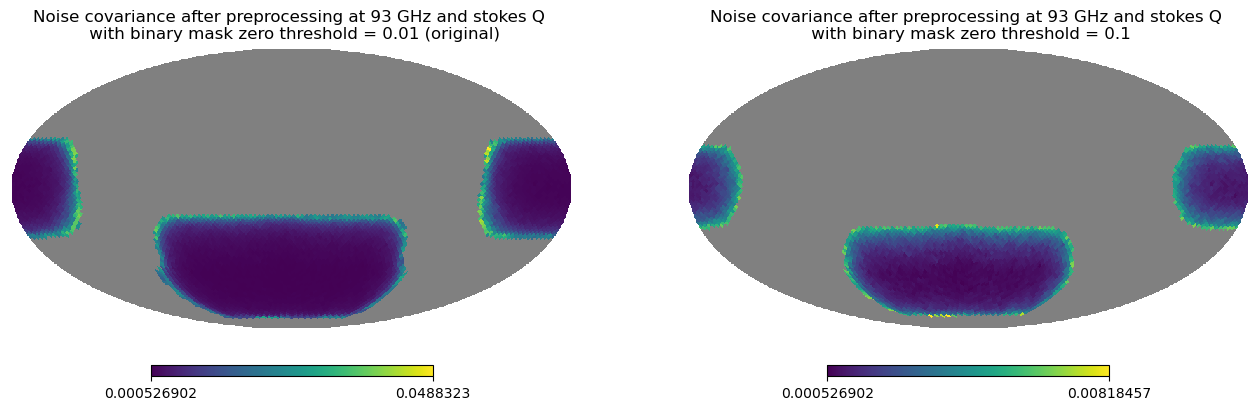

In [43]:
noise_cov_masked_afterpreproc250_CENTRE = np.copy(noise_cov_masked_afterpreproc250)
noise_cov_masked_afterpreproc250_CENTRE[..., np.where(binary_centre == 0)[0]] = hp.UNSEEN

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
min_noise_cov_plot = np.min([np.min(noise_cov_masked_afterpreproc250_CENTRE[2,1, np.where(noise_cov_masked_afterpreproc250_CENTRE != hp.UNSEEN)[-1]]), 
                             np.min(noise_cov_masked_afterpreproc250[2,1, np.where(noise_cov_masked_afterpreproc250 != hp.UNSEEN)[-1]])])
max_noise_cov_plot = np.max([np.max(noise_cov_masked_afterpreproc250_CENTRE[2,1]), np.max(noise_cov_masked_afterpreproc250[2,1])])

print('Using the same colorbar for both plots (rescaled) for easier comparison')
plt.sca(axes[0])
hp.mollview(noise_cov_masked_afterpreproc250[2,1], title='Noise covariance after preprocessing at 93 GHz and stokes Q \n with binary mask zero threshold = {} (original)'.format(meta_250.masks['mask_handler_binary_zero_threshold']), hold=True,
            min=min_noise_cov_plot, max=max_noise_cov_plot)
plt.sca(axes[1])
hp.mollview(noise_cov_masked_afterpreproc250_CENTRE[2,1], title='Noise covariance after preprocessing at 93 GHz and stokes Q \n with binary mask zero threshold = {}'.format(zero_threshold_centre), hold=True,
            min=min_noise_cov_plot, max=max_noise_cov_plot)

plt.show()

print('With default colorbar')

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0])
hp.mollview(noise_cov_masked_afterpreproc250[2,1], title='Noise covariance after preprocessing at 93 GHz and stokes Q \n with binary mask zero threshold = {} (original)'.format(meta_250.masks['mask_handler_binary_zero_threshold']), hold=True)
plt.sca(axes[1])
hp.mollview(noise_cov_masked_afterpreproc250_CENTRE[2,1], title='Noise covariance after preprocessing at 93 GHz and stokes Q \n with binary mask zero threshold = {}'.format(zero_threshold_centre), hold=True)

plt.show()

In [44]:
# Proceeding with the separation on all 250 simulations
results_array_CENTRE = []
sigma_array_CENTRE = []

for sim_iter in tqdm(range(250)):
    freq_maps_masked_afterpreproc250_CENTRE = np.load(os.path.join(meta_250.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_iter).zfill(5)+'.npy' )) 
    # Applying mask as it is not done in the simulation
    freq_maps_masked_afterpreproc250_CENTRE[..., np.where(binary_centre == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)
    res_masked_afterpreproc250_iter_CENTRE = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc250_CENTRE[:,1:], cov=noise_cov_masked_afterpreproc250_CENTRE[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
    if res_masked_afterpreproc250_iter_CENTRE.success:
        results_array_CENTRE.append(res_masked_afterpreproc250_iter_CENTRE.x)
        sigma_array_CENTRE.append(res_masked_afterpreproc250_iter_CENTRE.Sigma)
    # We can now check the results
    # print('iter #:', sim_iter, ',  success: ',res_masked_afterpreproc250_iter.success, ',  x: ', res_masked_afterpreproc250_iter.x)
results_array_CENTRE = np.array(results_array_CENTRE)
sigma_array_CENTRE = np.array(sigma_array_CENTRE)

100%|██████████| 250/250 [10:11<00:00,  2.44s/it]


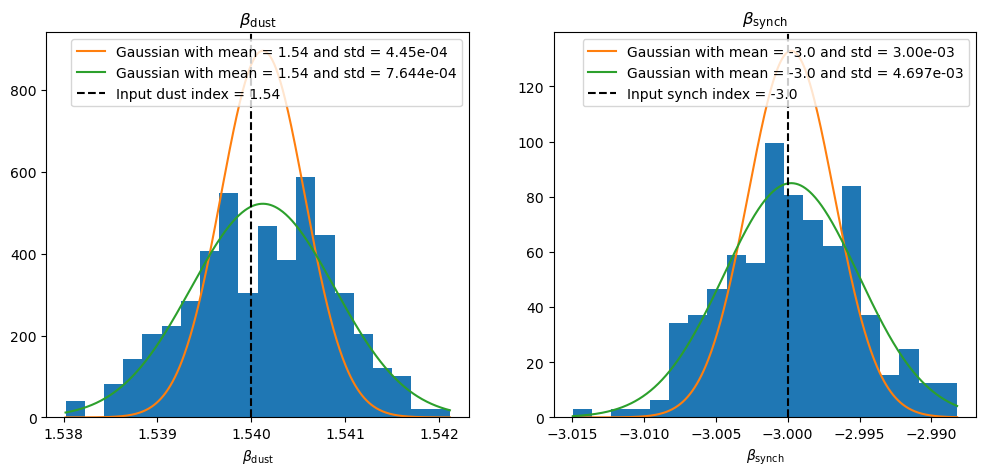

In [45]:
plot_hist_and_gaussian(results_array_CENTRE, sigma_array_CENTRE, sky)
